# Climatology Model Evaluation

Evaluates a trained model against the test split.

Set `TRAINING_DIR` to any training directory. Preprocessed data is read
from `training_dir/../data/` (the standard experiment layout).

**Plots produced**
1. Training loss curve
2. Truth vs prediction profiles (random sample)
3. Error profiles by latitude
4. Scatter: predicted vs truth at each latitude
5. Per-sample error distribution

In [32]:
import csv
import warnings
from pathlib import Path

import h5py
import numpy as np
import matplotlib.pyplot as plt
import torch
from tqdm.notebook import tqdm

from ml.config import load as load_config
from ml.data.climatology import is_climatology_var
from ml.diagnostics.spatial import cosine_latitude_weights
from ml.training.model import build_model
from ml.visualization.training import plot_loss_curve

plt.rcParams["figure.dpi"] = 120

warnings.filterwarnings("ignore", message=".*resized since it had shape.*")
warnings.filterwarnings("ignore", message=".*MPS.*constant padding.*")

TRAINING_DIR = Path("../../output/barotropic_stirring-T85/training")

In [33]:
training_dir = TRAINING_DIR.resolve()
assert training_dir.exists(), f"training dir not found: {training_dir}"

cfg = load_config(training_dir / "config.toml")

data_dir = training_dir.parent / "data"
assert data_dir.exists(), f"data dir not found: {data_dir}"
assert (data_dir / "test.h5").exists(), f"test.h5 not found in {data_dir}"

print(f"training dir : {training_dir}")
print(f"data dir     : {data_dir}")

training dir : /Users/tal.glanzman/own/climatology/output/barotropic_stirring-T85/training
data dir     : /Users/tal.glanzman/own/climatology/output/barotropic_stirring-T85/data


## Load model

In [34]:
model = build_model(
    cfg.model,
    dropout=cfg.training.regularization.dropout,
    zonal_mean=True,
)

params_path = training_dir / "parameters.pt"
assert params_path.exists(), f"model parameters not found: {params_path}"
state_dict = torch.load(params_path, map_location="cpu", weights_only=False)
state_dict.pop("_metadata", None)
model.load_state_dict(state_dict)
model.eval()

norm_path = training_dir / "normalization.pt"
assert norm_path.exists(), f"normalization stats not found: {norm_path}"
norm = torch.load(norm_path, map_location="cpu", weights_only=True)

n_params = sum(p.numel() for p in model.parameters())
print(f"architecture : {cfg.model.architecture}  params: {n_params:,}")
print(f"x_vars: {cfg.data.x_vars}")
print(f"y_vars: {cfg.data.y_vars}")

architecture : sfno  params: 208,177
x_vars: ['vor']
y_vars: ['time_mean_zonal_mean_ucomp']


## Training loss curve

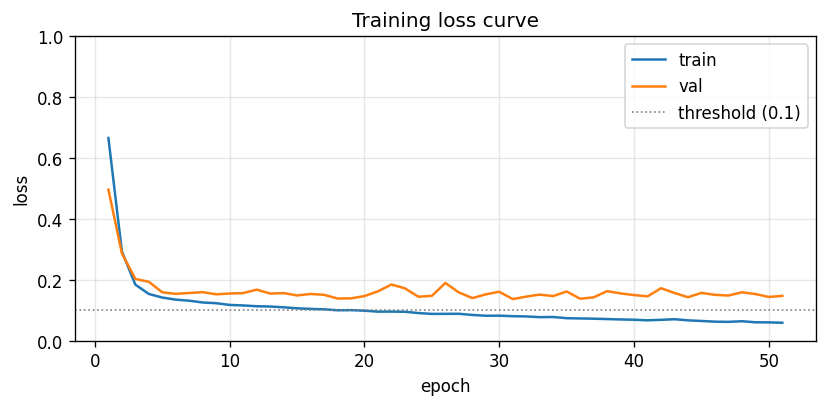

In [35]:
metrics_file = training_dir / "epoch-metrics.csv"
assert metrics_file.exists(), f"epoch-metrics.csv not found: {metrics_file}"

epochs, train_losses, val_losses = [], [], []
with open(metrics_file) as f:
    for row in csv.DictReader(f):
        epochs.append(int(row["epoch"]))
        train_losses.append(float(row["train_loss"]))
        v = row.get("val_loss", "")
        val_losses.append(float(v) if v else float("nan"))

fig, ax = plt.subplots(figsize=(7, 3.5))
plot_loss_curve(ax, epochs, train_losses, val_losses)
ax.set_title("Training loss curve")
plt.tight_layout()
plt.show()

## Evaluate test set

In [36]:
BATCH_SIZE = 64

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
print(f"device: {device}")

# Warm up SHT cache on CPU before moving to device.
# RealSHT (torch_harmonics) defaults to float64; warming on CPU casts it to float32
# first, so the subsequent .to(device) only moves float32 tensors -- which MPS supports.
# Afterwards clear the positional embedding grid cache: grid() caches by resolution
# but not device, so the CPU tensors would otherwise be reused on MPS.
if device.type != "cpu":
    with h5py.File(data_dir / "test.h5", "r") as f:
        dummy_shape = f["x"].shape[1:]
    model.cpu()
    with torch.no_grad():
        model(torch.zeros(1, *dummy_shape))
    for m in model.modules():
        if hasattr(m, "_grid"):
            m._grid = None

model.to(device)

with h5py.File(data_dir / "test.h5", "r") as f:
    x_test = torch.from_numpy(f["x"][:])
    y_test = torch.from_numpy(f["y"][:])

truth_all = y_test.squeeze(1).numpy()  # (N, H)
H = truth_all.shape[1]
lat = np.linspace(-90, 90, H)

norm_x_mean = norm["x_mean"].to(device)
norm_x_std  = norm["x_std"].to(device)
norm_y_mean = norm["y_mean"].to(device)
norm_y_std  = norm["y_std"].to(device)

preds_list = []
with torch.no_grad():
    for i in tqdm(range(0, len(x_test), BATCH_SIZE), desc="inference"):
        x_batch = x_test[i : i + BATCH_SIZE].to(device)
        x_norm = (x_batch - norm_x_mean) / norm_x_std
        y_norm = model(x_norm)
        y = y_norm * norm_y_std + norm_y_mean
        preds_list.append(y.squeeze(1).cpu())

preds_all = torch.cat(preds_list, dim=0).numpy()  # (N, H)
print(f"device: {device}  test samples: {len(truth_all)}  shape: {preds_all.shape}")

device: mps


inference:   0%|          | 0/8 [00:00<?, ?it/s]

device: mps  test samples: 495  shape: (495, 128)


## Metrics

In [37]:
def rel_l2(pred, truth, lat):
    w = cosine_latitude_weights(lat)
    return float(np.sqrt(np.sum(w * (pred - truth) ** 2) / np.sum(w * truth ** 2)))


def rmse(pred, truth, lat):
    w = cosine_latitude_weights(lat)
    return float(np.sqrt(np.sum(w * (pred - truth) ** 2) / np.sum(w)))


rmses = np.array([rmse(preds_all[i], truth_all[i], lat) for i in range(len(preds_all))])
rels  = np.array([rel_l2(preds_all[i], truth_all[i], lat) for i in range(len(preds_all))])

print(f"{'metric':<10} {'mean':>10} {'median':>10} {'p75':>10} {'p95':>10} {'max':>10}")
print("-" * 60)
for name, vals in [("rmse", rmses), ("relL2", rels)]:
    print(
        f"{name:<10} {vals.mean():>10.4f} {np.median(vals):>10.4f}"
        f" {np.percentile(vals, 75):>10.4f} {np.percentile(vals, 95):>10.4f} {vals.max():>10.4f}"
    )

metric           mean     median        p75        p95        max
------------------------------------------------------------
rmse           0.6363     0.5910     0.7911     1.1551     1.9083
relL2          0.1942     0.1767     0.2486     0.3857     0.6280


## Truth vs prediction profiles

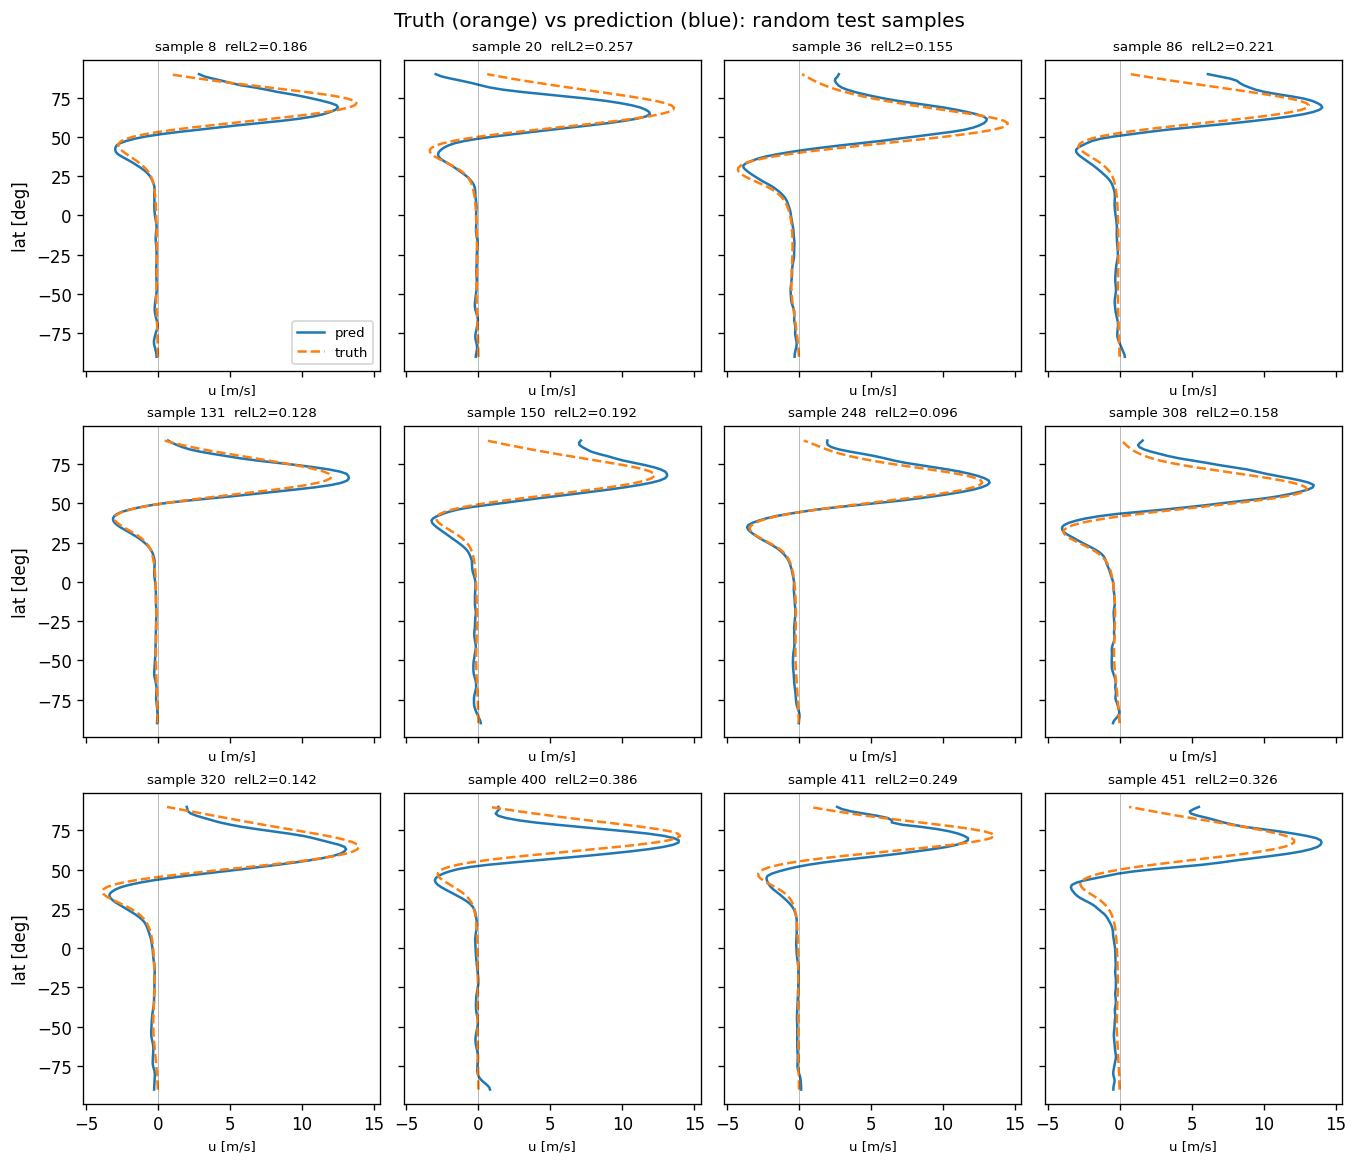

In [38]:
N_SHOW = 12
rng = np.random.default_rng(0)
idx = np.sort(rng.choice(len(preds_all), size=min(N_SHOW, len(preds_all)), replace=False))

ncols = 4
nrows = (len(idx) + ncols - 1) // ncols
fig, axes = plt.subplots(
    nrows, ncols,
    figsize=(ncols * 2.8, nrows * 3.2),
    sharex=True, sharey=True,
    constrained_layout=True,
)
axes_flat = list(np.array(axes).flat)

for k, i in enumerate(idx):
    ax = axes_flat[k]
    ax.plot(preds_all[i], lat, color="tab:blue", linewidth=1.5, label="pred")
    ax.plot(truth_all[i], lat, color="tab:orange", linestyle="--", linewidth=1.5, label="truth")
    ax.axvline(0.0, color="k", linewidth=0.4, alpha=0.4)
    rl = rel_l2(preds_all[i], truth_all[i], lat)
    ax.set_title(f"sample {i}  relL2={rl:.3f}", fontsize=8)
    ax.set_xlabel("u [m/s]", fontsize=8)
    if k % ncols == 0:
        ax.set_ylabel("lat [deg]")
    if k == 0:
        ax.legend(fontsize=8)

for ax in axes_flat[len(idx):]:
    ax.set_visible(False)

fig.suptitle("Truth (orange) vs prediction (blue): random test samples")
plt.show()

## Error profiles by latitude

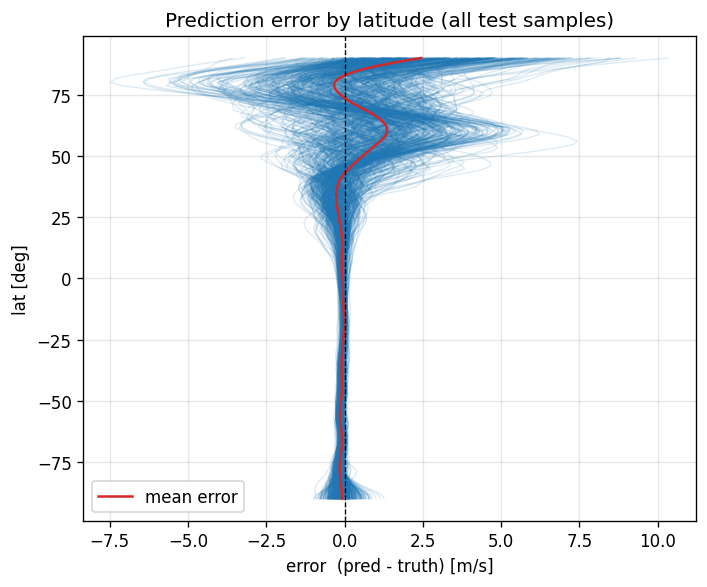

In [39]:
fig, ax = plt.subplots(figsize=(6, 5))
for i in range(len(preds_all)):
    ax.plot(preds_all[i] - truth_all[i], lat, alpha=0.15, linewidth=0.8, color="tab:blue")
mean_err = (preds_all - truth_all).mean(axis=0)
ax.plot(mean_err, lat, color="tab:red", linewidth=1.5, label="mean error")
ax.axvline(0.0, color="k", linewidth=0.8, linestyle="--")
ax.set_xlabel("error  (pred - truth) [m/s]")
ax.set_ylabel("lat [deg]")
ax.set_title("Prediction error by latitude (all test samples)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Scatter: predicted vs truth

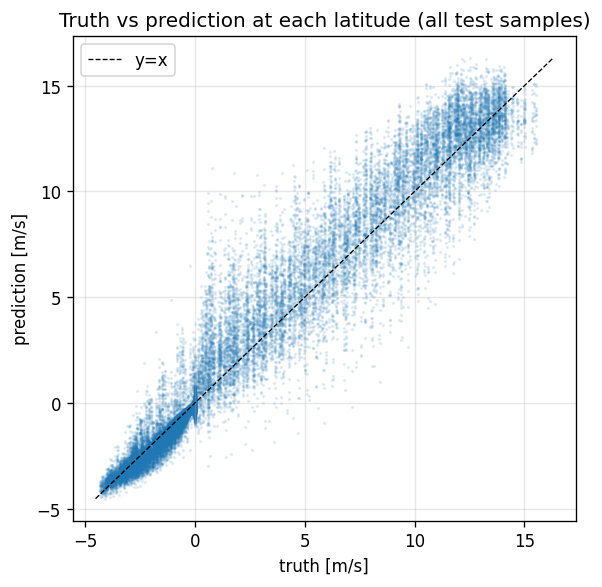

In [40]:
fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(truth_all.ravel(), preds_all.ravel(), s=1, alpha=0.1, color="tab:blue")
lo = min(truth_all.min(), preds_all.min())
hi = max(truth_all.max(), preds_all.max())
ax.plot([lo, hi], [lo, hi], "k--", linewidth=0.8, label="y=x")
ax.set_xlabel("truth [m/s]")
ax.set_ylabel("prediction [m/s]")
ax.set_title("Truth vs prediction at each latitude (all test samples)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Per-sample error distribution

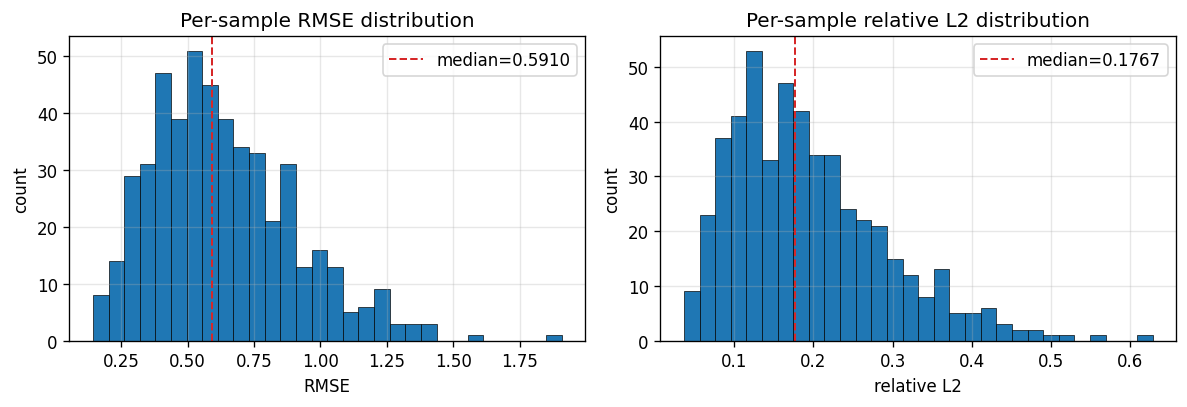

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))

for ax, name, vals in [(axes[0], "RMSE", rmses), (axes[1], "relative L2", rels)]:
    ax.hist(vals, bins=30, edgecolor="k", linewidth=0.4)
    ax.axvline(
        np.median(vals), color="tab:red", linewidth=1.2, linestyle="--",
        label=f"median={np.median(vals):.4f}",
    )
    ax.set_xlabel(name)
    ax.set_ylabel("count")
    ax.set_title(f"Per-sample {name} distribution")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()